<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پزشک قطعه‌ها
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین قصد داریم تا آستانه گذاری را روی تصاویر پزشکی بررسی کنیم و کاربردهای مختلف آنرا مشاهده کنیم.
</font>
</p>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش اول: قطعه‌بندی اسکلت
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش می‌خواهیم با استفاده از آستانه‌گذاری، اسکلت موجود در تصویر را از پیش‌زمینه متمایز کنیم. در ادامه با جزئیات این بخش بیشتر آشنا خواهیم شد.
</font>
</p>

---

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را بصورت خاکستری بخوانید.
<br>
Data/Skeleton.tif
</font>
</p>


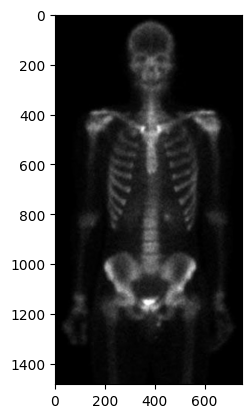

In [10]:
img = cv2.imread('./Data/Skeleton.tif')
plt.imshow(img)


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: تشخیص آستانه
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این قسمت تصویر اسکلت را با استفاده از روش اتسو قطعه‌بندی کنید. ابتدا آستانه را پیدا کنید و سپس تصویر قطعه‌بندی شده را ذخیره کنید.
</font>
</p>

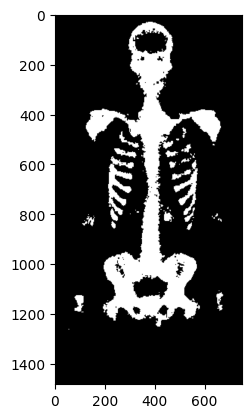

In [13]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
otsu_threshold, otsu_img = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(otsu_img, cmap='gray')

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: ذخیره تصویر</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
تصویر قطعه‌بندی شده را با نام زیر ذخیره کنید. دقت کنید که تصویر را حتما به شکل RGB ذخیره کنید.
<br>
segment_skeleton.tif
</font>
</p>

In [14]:
otsu_rgb = cv2.cvtColor(otsu_img, cv2.COLOR_GRAY2RGB)
cv2.imwrite('segment_skeleton.tif', otsu_rgb)

True

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش دوم: قطعه‌بندی قفسه سینه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش می‌خواهیم که عکس x-ray قفسه سینه یک انسان را قطعه‌بندی کنیم. در ادامه با مراحل اینکار آشنا خواهید شد.
</font>
</p>

---

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را بصورت خاکستری بخوانید.
<br>
Data/chest.webp
</font>
</p>


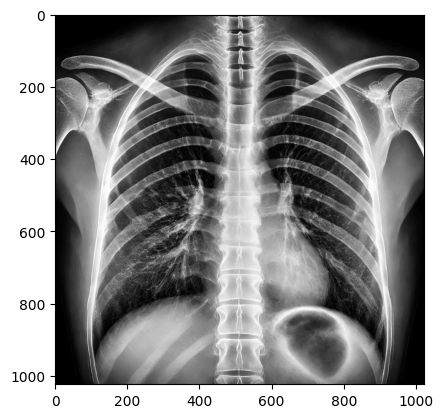

In [31]:
img = cv2.imread('./Data/chest.webp')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: اعمال آستانه‌گذاری باندی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
تصویر را با توجه به باندهای زیر آستانه‌گذاری کنید.
<br>
</font>
</p>

$$
D = \left\{ (0, 50), (51, 100), (101, 150), (151, 200), (201, 255) \right\}
$$

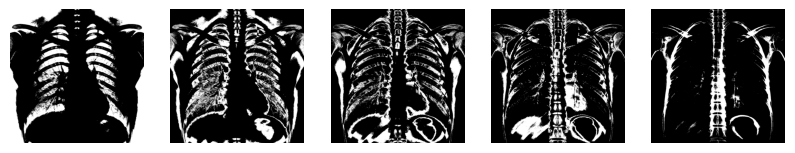

In [39]:
img1 = cv2.inRange(gray_img, 0, 50)
img2 = cv2.inRange(gray_img, 51, 100)
img3 = cv2.inRange(gray_img, 101, 150)
img4 = cv2.inRange(gray_img, 151, 200)
img5 = cv2.inRange(gray_img, 201, 255)


imgs = [img1, img2, img3, img4, img5]

plt.figure(figsize=(10, 2))
for i, im in enumerate(imgs, 1):
    plt.subplot(1, 5, i)
    plt.imshow(im, cmap='gray')
    plt.axis('off')

plt.show()


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله چهارم: ذخیره‌سازی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
خروجی هر باند را با نام‌های زیر ذخیره کنید. دقت کنید که تصاویر را به شکل RGB ذخیره کنید.
<br>
chest_0_50.jpg
<br>
chest_51_100.jpg
<br>
chest_101_150.jpg
<br>
chest_151_200.jpg
<br>
chest_201_255.jpg
</font>
</p>

In [40]:
img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_GRAY2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_GRAY2RGB)
img5 = cv2.cvtColor(img5, cv2.COLOR_GRAY2RGB)

cv2.imwrite('chest_0_50.jpg', img1)
cv2.imwrite('chest_51_100.jpg', img2)
cv2.imwrite('chest_101_150.jpg', img3)
cv2.imwrite('chest_151_200.jpg', img4)
cv2.imwrite('chest_201_255.jpg', img5)


True

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله پنجم: سلول جواب‌ساز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بدون هیچگونه تغییری، این سلول را اجرا کنید تا فایل پاسخ شما آماده شود.
</font>
</p>

In [41]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["notebook.ipynb", "segment_skeleton.tif", 'chest_0_50.jpg', 'chest_51_100.jpg', 'chest_101_150.jpg', 'chest_151_200.jpg', 'chest_201_255.jpg']
compress(file_names)

File Paths:
['notebook.ipynb', 'segment_skeleton.tif', 'chest_0_50.jpg', 'chest_51_100.jpg', 'chest_101_150.jpg', 'chest_151_200.jpg', 'chest_201_255.jpg']
